In [6]:
import fitz  # PyMuPDF
import re
import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import pandas as pd

def extract_section_names_from_pdf(pdf_path: str, output_dir: Optional[str] = None) -> Dict[int, str]:
    """
    Extract section names from each page of a PDF file.
    
    Args:
        pdf_path: Path to the PDF file
        output_dir: Optional directory to save results
        
    Returns:
        Dictionary mapping page numbers to section names
    """
    doc = fitz.open(pdf_path)
    page_sections = {}
    
    for page_num in range(doc.page_count):
        page = doc[page_num]
        text = page.get_text()
        
        # Extract section name using various patterns
        section_name = extract_section_from_text(text, page_num + 1)
        page_sections[page_num + 1] = section_name
        
        print(f"Page {page_num + 1}: {section_name}")
    
    doc.close()
    
    # Save results if output directory is specified
    if output_dir:
        output_path = Path(output_dir)
        output_path.mkdir(exist_ok=True, parents=True)
        
        pdf_name = Path(pdf_path).stem
        results_file = output_path / f"{pdf_name}_sections.json"
        
        with open(results_file, 'w', encoding='utf-8') as f:
            json.dump(page_sections, f, indent=2, ensure_ascii=False)
        
        print(f"\nResults saved to: {results_file}")
    
    return page_sections

def extract_section_from_text(text: str, page_num: int) -> str:
    """
    Extract section name from page text using various patterns.
    
    Args:
        text: Raw text from the PDF page
        page_num: Page number for context
        
    Returns:
        Extracted section name or 'UNKNOWN SECTION' if not found
    """
    lines = text.split('\n')
    
    # Clean and filter lines
    clean_lines = []
    for line in lines:
        clean_line = line.strip()
        if clean_line and len(clean_line) > 2:  # Skip very short lines
            clean_lines.append(clean_line)
    
    if not clean_lines:
        return "UNKNOWN SECTION"
    
    # Pattern 1: Look for ALL CAPS lines (common for section headers)
    for i, line in enumerate(clean_lines[:10]):  # Check first 10 lines
        if line.isupper() and len(line) > 5 and not line.isdigit():
            # Skip page numbers and common headers
            if not any(skip_word in line for skip_word in ['PAGE', 'ANNUAL REPORT', 'VOLKSWAGEN', 'GROUP']):
                # Check if it's not just a date or number
                if not re.match(r'^[\d\s\/\-\.]+$', line):
                    return clean_section_name(line)
    
    # Pattern 2: Look for numbered sections (e.g., "1. MANAGEMENT REPORT")
    for line in clean_lines[:15]:
        match = re.match(r'^(\d+\.?\s*)?([A-Z][A-Z\s&\-\']+)$', line)
        if match:
            section = match.group(2).strip()
            if len(section) > 5:
                return clean_section_name(section)
    
    # Pattern 3: Look for lines with specific section keywords
    section_keywords = [
        'MANAGEMENT REPORT', 'FINANCIAL STATEMENTS', 'CONSOLIDATED FINANCIAL',
        'BALANCE SHEET', 'INCOME STATEMENT', 'CASH FLOW', 'EQUITY',
        'NOTES', 'AUDITOR', 'CORPORATE GOVERNANCE', 'SUSTAINABILITY',
        'DIVISIONS', 'BUSINESS DEVELOPMENT', 'OUTLOOK', 'RISK MANAGEMENT',
        'COMBINED MANAGEMENT REPORT', 'GROUP MANAGEMENT REPORT'
    ]
    
    for line in clean_lines[:20]:
        line_upper = line.upper()
        for keyword in section_keywords:
            if keyword in line_upper:
                return clean_section_name(line_upper)
    
    # Pattern 4: Look for title-case section headers
    for line in clean_lines[:15]:
        if re.match(r'^[A-Z][a-z]+(\s[A-Z][a-z]+)*$', line) and len(line) > 8:
            return clean_section_name(line.upper())
    
    # Pattern 5: Try to find any prominent heading (longer lines that appear early)
    for line in clean_lines[:8]:
        if len(line) > 10 and len(line) < 80:
            # Check if it looks like a heading (not too many numbers)
            if len(re.findall(r'\d', line)) / len(line) < 0.3:
                return clean_section_name(line.upper())
    
    return "UNKNOWN SECTION"

def clean_section_name(section: str) -> str:
    """Clean and standardize section names."""
    # Remove extra whitespace
    section = ' '.join(section.split())
    
    # Remove common prefixes/suffixes
    section = re.sub(r'^(TO\s+THE\s+|THE\s+)', '', section, flags=re.IGNORECASE)
    section = re.sub(r'\s*(CONTINUED|CONT\'D)\s*$', '', section, flags=re.IGNORECASE)
    
    # Remove trailing periods and numbers
    section = re.sub(r'[\.\d\s]*$', '', section).strip()
    
    return section

# Test with a single PDF file
test_pdf = r"C:\Users\karim\dev\time-stamped-kpi-graph\kpi_extraction_project\data\input_test\divisions_vw_ar15.pdf"
output_dir = r"C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction"

print("Extracting section names from:", test_pdf)
print("=" * 60)

sections = extract_section_names_from_pdf(test_pdf, output_dir)

Extracting section names from: C:\Users\karim\dev\time-stamped-kpi-graph\kpi_extraction_project\data\input_test\divisions_vw_ar15.pdf
Page 1: DIVISIONS
Page 2: 28 ŠKODA
Page 3: VOLKSWAGEN GROU P
Page 4: KEY FIGU RES BY MARKET
Page 5: DIVISIONS
Page 6: BUSI N ESS DEVELOPMENT
Page 7: PRODUCTION
Page 8: BUSI N ESS DEVELOPMENT
Page 9: PRODUCTION
Page 10: DIVISIONS
Page 11: PRODUCTION
Page 12: BUSI N ESS DEVELOPMENT
Page 13: PRODUCTION
Page 14: BUSI N ESS DEVELOPMENT
Page 15: PRODUCTION
Page 16: BUSI N ESS DEVELOPMENT
Page 17: PRODUCTION
Page 18: BUSI N ESS DEVELOPMENT
Page 19: PRODUCTION
Page 20: DIVISIONS
Page 21: PRODUCTION
Page 22: BUSI N ESS DEVELOPMENT
Page 23: PRODUCTION
Page 24: BUSI N ESS DEVELOPMENT
Page 25: DIVISIONS
Page 26: BUSI N ESS DEVELOPMENT
Page 27: CUSTOMERS IN PUERTO RICO BUYING NEW VEHICLES
Page 28: SALES REVENU E AND EARN INGS

Results saved to: C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction\divisions_vw_ar15_sections.json


In [17]:
# Import PyMuPDF Layout first to activate layout detection features
import pymupdf.layout  # Must be imported BEFORE pymupdf4llm to activate layout feature
import pymupdf4llm
import pymupdf
import json  # Add missing json import

def convert_rect_to_dict(obj):
    """Convert PyMuPDF Rect objects to dictionaries for JSON serialization"""
    if hasattr(obj, '__dict__'):
        return obj.__dict__
    elif hasattr(obj, 'x0') and hasattr(obj, 'y0'):  # Rect object
        return {'x0': obj.x0, 'y0': obj.y0, 'x1': obj.x1, 'y1': obj.y1}
    else:
        return str(obj)

def make_json_serializable(obj):
    """Recursively convert objects to make them JSON serializable"""
    if isinstance(obj, list):
        return [make_json_serializable(item) for item in obj]
    elif isinstance(obj, dict):
        return {key: make_json_serializable(value) for key, value in obj.items()}
    elif hasattr(obj, 'x0') and hasattr(obj, 'y0'):  # PyMuPDF Rect object
        return {'x0': obj.x0, 'y0': obj.y0, 'x1': obj.x1, 'y1': obj.y1}
    elif hasattr(obj, '__dict__'):
        return make_json_serializable(obj.__dict__)
    else:
        return obj

# Convert PDF to markdown using pymupdf4llm with layout detection
pdf_file = r"C:\Users\karim\dev\time-stamped-kpi-graph\kpi_extraction_project\data\input_test\divisions_vw_ar15.pdf"

print("Converting PDF using PyMuPDF4LLM with Layout Detection (First 10 Pages)...")
print("=" * 70)

try:
    # Open the PDF document
    doc = pymupdf.open(pdf_file)
    print(f"Opened PDF: {Path(pdf_file).name}")
    print(f"Total pages in PDF: {doc.page_count}")
    print(f"Processing pages: 1-10")
    print("=" * 70)
    
    # Extract structured markdown with layout detection - first 10 pages only
    md_text = pymupdf4llm.to_markdown(pdf_file, pages=list(range(10)), use_ocr=True)
    
    print("MARKDOWN OUTPUT with Layout Detection:")
    print("=" * 70)
    print(md_text[:3000])  # Show first 3000 chars for display
    if len(md_text) > 3000:
        print(f"\n... (truncated - full text has {len(md_text)} characters)")
    print("\n" + "=" * 70)
    
    # Extract as JSON format
    json_data = pymupdf4llm.to_markdown(pdf_file, pages=list(range(10)), page_chunks=True, use_ocr=True)
    
    print("SECTION EXTRACTION SUMMARY:")
    print("=" * 70)
    for i, page_data in enumerate(json_data[:10]):  # First 10 pages
        page_num = page_data['metadata']['page']
        text_preview = page_data['text'][:200].replace('\n', ' ').strip()
        if text_preview:
            print(f"Page {page_num}: {text_preview}...")
        else:
            print(f"Page {page_num}: [No text content]")
    print("\n" + "=" * 70)
    
    # Save both outputs to files
    output_dir = Path(r"C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction")
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Save markdown
    md_output_file = output_dir / "pdf_markdown_layout_first_10_pages.md"
    with open(md_output_file, 'w', encoding='utf-8') as f:
        f.write(md_text)
    
    # Save JSON with proper serialization
    json_output_file = output_dir / "pdf_json_layout_first_10_pages.json"
    with open(json_output_file, 'w', encoding='utf-8') as f:
        # Make the data JSON serializable
        serializable_data = make_json_serializable(json_data)
        json.dump(serializable_data, f, indent=2, ensure_ascii=False)
    
    # Create a summary of sections extracted
    sections_summary = {}
    for page_data in json_data:
        page_num = page_data['metadata']['page']
        text_content = page_data['text']
        
        # Extract section name from the text
        lines = text_content.split('\n')
        section_name = "UNKNOWN"
        for line in lines[:10]:
            line = line.strip()
            if line and line.startswith('**') and line.endswith('**'):
                section_name = line.replace('**', '').strip()
                break
            elif line and line.startswith('_') and line.endswith('_'):
                section_name = line.replace('_', '').strip()
                break
        
        sections_summary[page_num] = {
            'section_name': section_name,
            'has_tables': len(page_data.get('tables', [])) > 0,
            'has_images': len(page_data.get('images', [])) > 0,
            'text_length': len(text_content)
        }
    
    # Save sections summary
    summary_file = output_dir / "sections_summary.json" 
    with open(summary_file, 'w', encoding='utf-8') as f:
        json.dump(sections_summary, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Markdown output saved to: {md_output_file}")
    print(f"✅ JSON output saved to: {json_output_file}")
    print(f"✅ Sections summary saved to: {summary_file}")
    
    # Close the document
    doc.close()
    
    print("\n🎉 SUCCESS: Section extraction completed with layout detection!")
    
except Exception as e:
    print(f"Error converting PDF: {e}")
    import traceback
    traceback.print_exc()

Converting PDF using PyMuPDF4LLM with Layout Detection (First 10 Pages)...
Opened PDF: divisions_vw_ar15.pdf
Total pages in PDF: 28
Processing pages: 1-10
Warning - arguments ignored in legacy mode: {'use_ocr'}.
MARKDOWN OUTPUT with Layout Detection:
# 2

### _Divisions_

**UNIT SALES BY MARKET, 2015 VS. 2014** _(in percent)_






**DIVISIONS**



**21** Brands and Business Fields

**24** Volkswagen Passenger Cars

**26** Audi

**28** ŠKODA

**30** SEAT

**32** Bentley

**34** Porsche

**36** Volkswagen Commercial Vehicles

**38** Scania

**40** MAN

**42** Volkswagen Group China

**44** Volkswagen Financial Services


**DIVISIONS**
_Brands and Business Fields_

### _Brands and_ _Business Fields_


The Group brands operated in a continuously challenging market environment in 2015,
facing fierce competition. Special items – particularly from the emissions issue –
significantly affected the operating result.


**GROU P STRUCTU RE**
The Volkswagen Group consists of two divisions: the Aut

In [19]:
# Adding Artificial Top Padding to PDF Page Images for Better OCR Detection
import fitz  # PyMuPDF
import json
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

print("Adding Artificial Top Padding to PDF Pages for Better OCR Detection")
print("=" * 75)

def convert_pdf_page_with_top_padding(page: fitz.Page, dpi: int = 300, top_padding_px: int = 150) -> Image.Image:
    """
    Convert a PDF page to a PIL Image with artificial white padding added to the top.
    
    This technique helps OCR detectors by:
    1. Moving section headers away from the image boundary
    2. Preventing suppression of text near edges
    3. Improving header detection accuracy
    
    Args:
        page: PyMuPDF page object
        dpi: Resolution for rendering (default: 300 for high quality)
        top_padding_px: Pixels of white padding to add above the content
        
    Returns:
        PIL Image object with top padding
    """
    # First, render the page at specified DPI
    zoom = dpi / 72  # 72 DPI is PDF default
    matrix = fitz.Matrix(zoom, zoom)
    pixmap = page.get_pixmap(matrix=matrix)
    
    # Convert to PIL Image
    original_img = Image.frombytes("RGB", [pixmap.width, pixmap.height], pixmap.samples)
    
    # Create new image with additional height for top padding
    padded_width = original_img.width
    padded_height = original_img.height + top_padding_px
    
    # Create new image with white background
    padded_img = Image.new('RGB', (padded_width, padded_height), 'white')
    
    # Paste the original image below the padding
    padded_img.paste(original_img, (0, top_padding_px))
    
    return padded_img

# Test with the PDF file
pdf_file = r"C:\Users\karim\dev\time-stamped-kpi-graph\kpi_extraction_project\data\input_test\divisions_vw_ar15.pdf"
output_dir = Path(r"C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction\padded_images")
output_dir.mkdir(parents=True, exist_ok=True)

try:
    # Open the PDF document
    doc = fitz.open(pdf_file)
    print(f"📄 Processing: {Path(pdf_file).name}")
    print(f"📊 Total pages: {doc.page_count}")
    print(f"📁 Output directory: {output_dir}")
    print("=" * 75)
    
    # Test different padding values
    padding_tests = [
        (0, "no_padding", "Original (No Padding)"),
        (100, "100px_padding", "100px Top Padding"),  
        (150, "150px_padding", "150px Top Padding"),
        (200, "200px_padding", "200px Top Padding")
    ]
    
    # Process first 3 pages with different padding values
    pages_to_test = min(3, doc.page_count)
    
    for page_num in range(pages_to_test):
        page = doc[page_num]
        
        print(f"\n📄 PROCESSING PAGE {page_num + 1}:")
        print("-" * 50)
        
        for padding_px, folder_name, description in padding_tests:
            print(f"🎨 Creating {description}...")
            
            # Create padded image
            if padding_px == 0:
                # Original image without padding
                zoom = 300 / 72  # 300 DPI
                matrix = fitz.Matrix(zoom, zoom)
                pixmap = page.get_pixmap(matrix=matrix)
                page_image = Image.frombytes("RGB", [pixmap.width, pixmap.height], pixmap.samples)
            else:
                # Image with top padding
                page_image = convert_pdf_page_with_top_padding(page, dpi=300, top_padding_px=padding_px)
            
            # Create subdirectory for this padding test
            padding_dir = output_dir / folder_name
            padding_dir.mkdir(parents=True, exist_ok=True)
            
            # Save the image
            image_filename = f"page_{page_num + 1:02d}_{folder_name}.png"
            image_path = padding_dir / image_filename
            page_image.save(image_path)
            
            # Get image dimensions
            width, height = page_image.size
            
            print(f"   ✅ Saved: {image_filename}")
            print(f"   📐 Dimensions: {width}x{height}px")
            if padding_px > 0:
                original_height = height - padding_px
                print(f"   📏 Original: {width}x{original_height}px + {padding_px}px padding = {width}x{height}px")
            
            # Create a visual comparison by adding text overlay showing the padding area
            if padding_px > 0:
                # Create a copy for annotation
                annotated_img = page_image.copy()
                draw = ImageDraw.Draw(annotated_img)
                
                # Draw a light border around the padding area
                padding_border_color = (200, 200, 255)  # Light blue
                draw.rectangle([(0, 0), (width-1, padding_px-1)], outline=padding_border_color, width=2)
                
                # Add text annotation
                try:
                    # Try to use a default font, fallback to basic if not available
                    font = ImageFont.load_default()
                except:
                    font = None
                
                text = f"TOP PADDING: {padding_px}px"
                text_bbox = draw.textbbox((0, 0), text, font=font)
                text_width = text_bbox[2] - text_bbox[0]
                text_height = text_bbox[3] - text_bbox[1]
                
                # Center the text in the padding area
                text_x = (width - text_width) // 2
                text_y = (padding_px - text_height) // 2
                
                draw.text((text_x, text_y), text, fill=(100, 100, 100), font=font)
                
                # Save annotated version
                annotated_filename = f"page_{page_num + 1:02d}_{folder_name}_annotated.png"
                annotated_path = padding_dir / annotated_filename
                annotated_img.save(annotated_path)
                print(f"   🎯 Annotated: {annotated_filename}")
    
    # Create a summary comparison
    print(f"\n" + "=" * 75)
    print("📊 PADDING COMPARISON SUMMARY:")
    print("=" * 75)
    
    comparison_data = {}
    for padding_px, folder_name, description in padding_tests:
        comparison_data[folder_name] = {
            'description': description,
            'padding_pixels': padding_px,
            'purpose': 'Baseline' if padding_px == 0 else f'Move headers {padding_px}px from edge for better OCR detection',
            'folder': folder_name
        }
    
    # Save comparison summary
    summary_file = output_dir / "padding_comparison_summary.json"
    with open(summary_file, 'w', encoding='utf-8') as f:
        summary_data = {
            'source_pdf': Path(pdf_file).name,
            'pages_tested': pages_to_test,
            'dpi': 300,
            'padding_tests': comparison_data,
            'explanation': {
                'purpose': 'Add white padding above PDF content to improve OCR header detection',
                'problem': 'OCR detectors often suppress text too close to image boundaries',
                'solution': 'Artificial top padding moves section headers away from the top edge',
                'recommended_padding': '100-200 pixels for most use cases'
            }
        }
        json.dump(summary_data, f, indent=2, ensure_ascii=False)
    
    print("✅ Purpose: Move section headers away from image boundaries")
    print("✅ Benefit: Prevents OCR suppression of text near edges")
    print("✅ Recommendation: Use 100-200px padding for optimal results")
    
    print(f"\n📁 OUTPUT FILES:")
    for folder_name, data in comparison_data.items():
        folder_path = output_dir / folder_name
        if folder_path.exists():
            files = list(folder_path.glob("*.png"))
            print(f"   📂 {folder_name}/ ({data['description']})")
            for file in sorted(files):
                size = file.stat().st_size
                print(f"      - {file.name} ({size:,} bytes)")
    
    print(f"\n📄 Summary: {summary_file.name}")
    
    print(f"\n💡 USAGE TIPS:")
    print("1. Compare original vs padded images to see the effect")
    print("2. Use annotated versions to visualize padding area")  
    print("3. Test with your OCR system to find optimal padding")
    print("4. 150px is often a good balance between detection and file size")
    
    print(f"\n🔍 NEXT STEPS:")
    print("1. Run OCR on both original and padded images")
    print("2. Compare header detection rates")
    print("3. Integrate optimal padding into your processing pipeline")
    print("4. Consider different padding for different document types")
    
    doc.close()
    
    print(f"\n🎉 PADDING EXPERIMENT COMPLETE!")
    print("=" * 75)
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

Adding Artificial Top Padding to PDF Pages for Better OCR Detection
📄 Processing: divisions_vw_ar15.pdf
📊 Total pages: 28
📁 Output directory: C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction\padded_images

📄 PROCESSING PAGE 1:
--------------------------------------------------
🎨 Creating Original (No Padding)...
   ✅ Saved: page_01_no_padding.png
   📐 Dimensions: 2540x3367px
🎨 Creating 100px Top Padding...
   ✅ Saved: page_01_100px_padding.png
   📐 Dimensions: 2540x3467px
   📏 Original: 2540x3367px + 100px padding = 2540x3467px
   🎯 Annotated: page_01_100px_padding_annotated.png
🎨 Creating 150px Top Padding...
   ✅ Saved: page_01_150px_padding.png
   📐 Dimensions: 2540x3517px
   📏 Original: 2540x3367px + 150px padding = 2540x3517px
   🎯 Annotated: page_01_150px_padding_annotated.png
🎨 Creating 200px Top Padding...
   ✅ Saved: page_01_200px_padding.png
   📐 Dimensions: 2540x3567px
   📏 Original: 2540x3367px + 200px padding = 2540x3567px
   🎯 Annotated: page_01_20

In [ ]:
# Table Detection with 200px Top Padding
import subprocess
import sys
from pathlib import Path
import json

print("Running Table Detection with 200px Top Padding")
print("=" * 60)

# Configuration
input_pdf_dir = Path(r"C:\Users\karim\dev\time-stamped-kpi-graph\kpi_extraction_project\data\input_test")
output_dir = Path(r"C:\Users\karim\dev\time-stamped-kpi-graph\data\output\table_detection_200px_padding")
output_json = output_dir / "tables_with_200px_padding.json"

print(f"📁 Input PDF directory: {input_pdf_dir}")
print(f"📁 Output directory: {output_dir}")
print(f"📄 Output JSON: {output_json}")
print("🎨 Using 200px top padding for better OCR header detection")
print("=" * 60)

# Check if input directory exists
if not input_pdf_dir.exists():
    print(f"❌ Input directory not found: {input_pdf_dir}")
    print("Please make sure the PDF files are in the correct location")
else:
    # List PDF files
    pdf_files = list(input_pdf_dir.glob("*.pdf"))
    print(f"📄 Found {len(pdf_files)} PDF file(s):")
    for pdf_file in pdf_files:
        print(f"   - {pdf_file.name}")
    
    if pdf_files:
        # Ensure output directory exists
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Construct command for table detection with 200px padding
        cmd = [
            sys.executable,  # Use current Python interpreter
            "detect_tables.py",
            str(input_pdf_dir),
            str(output_json),
            "--output-dir", str(output_dir),
            "--dpi", "300",
            "--model-name", "tesseract", 
            "--top-padding", "200"  # Key parameter: 200px top padding
        ]
        
        print(f"\n🚀 Running command:")
        print(f"   {' '.join(cmd)}")
        print("\n" + "=" * 60)
        
        try:
            # Run the table detection
            result = subprocess.run(
                cmd,
                cwd=Path("./").resolve(),  # Run in current directory
                capture_output=True,
                text=True,
                timeout=300  # 5 minute timeout
            )
            
            print("📊 COMMAND OUTPUT:")
            print("-" * 40)
            if result.stdout:
                print(result.stdout)
            
            if result.stderr:
                print("\n⚠️  STDERR:")
                print(result.stderr)
            
            print(f"\n📈 Return code: {result.returncode}")
            
            if result.returncode == 0:
                print("\n✅ TABLE DETECTION COMPLETED SUCCESSFULLY!")
                
                # Check output files
                if output_json.exists():
                    with open(output_json, 'r', encoding='utf-8') as f:
                        results = json.load(f)
                    
                    tables = results.get('tables', [])
                    print(f"\n📋 RESULTS SUMMARY:")
                    print(f"   🎯 Tables detected: {len(tables)}")
                    
                    if tables:
                        # Group by PDF file
                        by_pdf = {}
                        for table in tables:
                            pdf_name = table['pdf_file']
                            if pdf_name not in by_pdf:
                                by_pdf[pdf_name] = []
                            by_pdf[pdf_name].append(table)
                        
                        for pdf_name, pdf_tables in by_pdf.items():
                            print(f"\n   📄 {pdf_name}: {len(pdf_tables)} table(s)")
                            for table in pdf_tables[:3]:  # Show first 3 tables
                                title = table.get('title', 'Untitled')
                                page = table.get('page', '?')
                                bbox = table.get('bbox', [])
                                print(f"      - Page {page}: {title[:50]}{'...' if len(title) > 50 else ''}")
                                if bbox:
                                    print(f"        BBox: {bbox}")
                            if len(pdf_tables) > 3:
                                print(f"      ... and {len(pdf_tables) - 3} more table(s)")
                        
                        print(f"\n📂 OUTPUT FILES:")
                        # List generated files
                        for pdf_file in pdf_files:
                            pdf_name = pdf_file.stem
                            pdf_output_dir = output_dir / pdf_name
                            if pdf_output_dir.exists():
                                print(f"   📁 {pdf_name}/")
                                for page_dir in sorted(pdf_output_dir.glob("page_*")):
                                    page_files = list(page_dir.glob("*"))
                                    print(f"      📄 {page_dir.name}/ ({len(page_files)} files)")
                                    
                                    # Show table images
                                    table_images = list(page_dir.glob("table_*.png"))
                                    if table_images:
                                        for img in table_images:
                                            size = img.stat().st_size
                                            print(f"         🖼️  {img.name} ({size:,} bytes)")
                    else:
                        print("   ⚠️  No tables detected")
                
                print(f"\n💡 KEY BENEFITS OF 200PX PADDING:")
                print("   ✅ Headers moved away from image boundaries")
                print("   ✅ Reduced OCR suppression near edges") 
                print("   ✅ Better section header detection")
                print("   ✅ Improved table title recognition")
                
            else:
                print(f"\n❌ TABLE DETECTION FAILED!")
                print(f"Return code: {result.returncode}")
                if result.stderr:
                    print(f"Error: {result.stderr}")
            
        except subprocess.TimeoutExpired:
            print("❌ Command timed out after 5 minutes")
        except Exception as e:
            print(f"❌ Error running command: {e}")
            import traceback
            traceback.print_exc()
    else:
        print("❌ No PDF files found in input directory")

print("\n" + "=" * 60)
print("🎯 PADDING-ENHANCED TABLE DETECTION COMPLETE")
print("=" * 60)

Splitting PDF Pages into Header and Content Sections
📄 Processing: divisions_vw_ar15.pdf
📊 Total pages: 28
📁 Output directory: C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction\split_images

📄 PROCESSING PAGE 1:
--------------------------------------------------
✂️  Creating 20% Header / 80% Content...
   ✅ Full page: 2540x3367px → page_01_full_annotated.png
   📋 Header: 2540x673px → page_01_header.png
   📊 Content: 2540x2694px → page_01_content.png
   📏 Split at: 673px (20% of 3367px)
✂️  Creating 25% Header / 75% Content...
   ✅ Full page: 2540x3367px → page_01_full_annotated.png
   📋 Header: 2540x841px → page_01_header.png
   📊 Content: 2540x2526px → page_01_content.png
   📏 Split at: 841px (25% of 3367px)
✂️  Creating 30% Header / 70% Content...
   ✅ Full page: 2540x3367px → page_01_full_annotated.png
   📋 Header: 2540x1010px → page_01_header.png
   📊 Content: 2540x2357px → page_01_content.png
   📏 Split at: 1010px (30% of 3367px)

📄 PROCESSING PAGE 2:
------

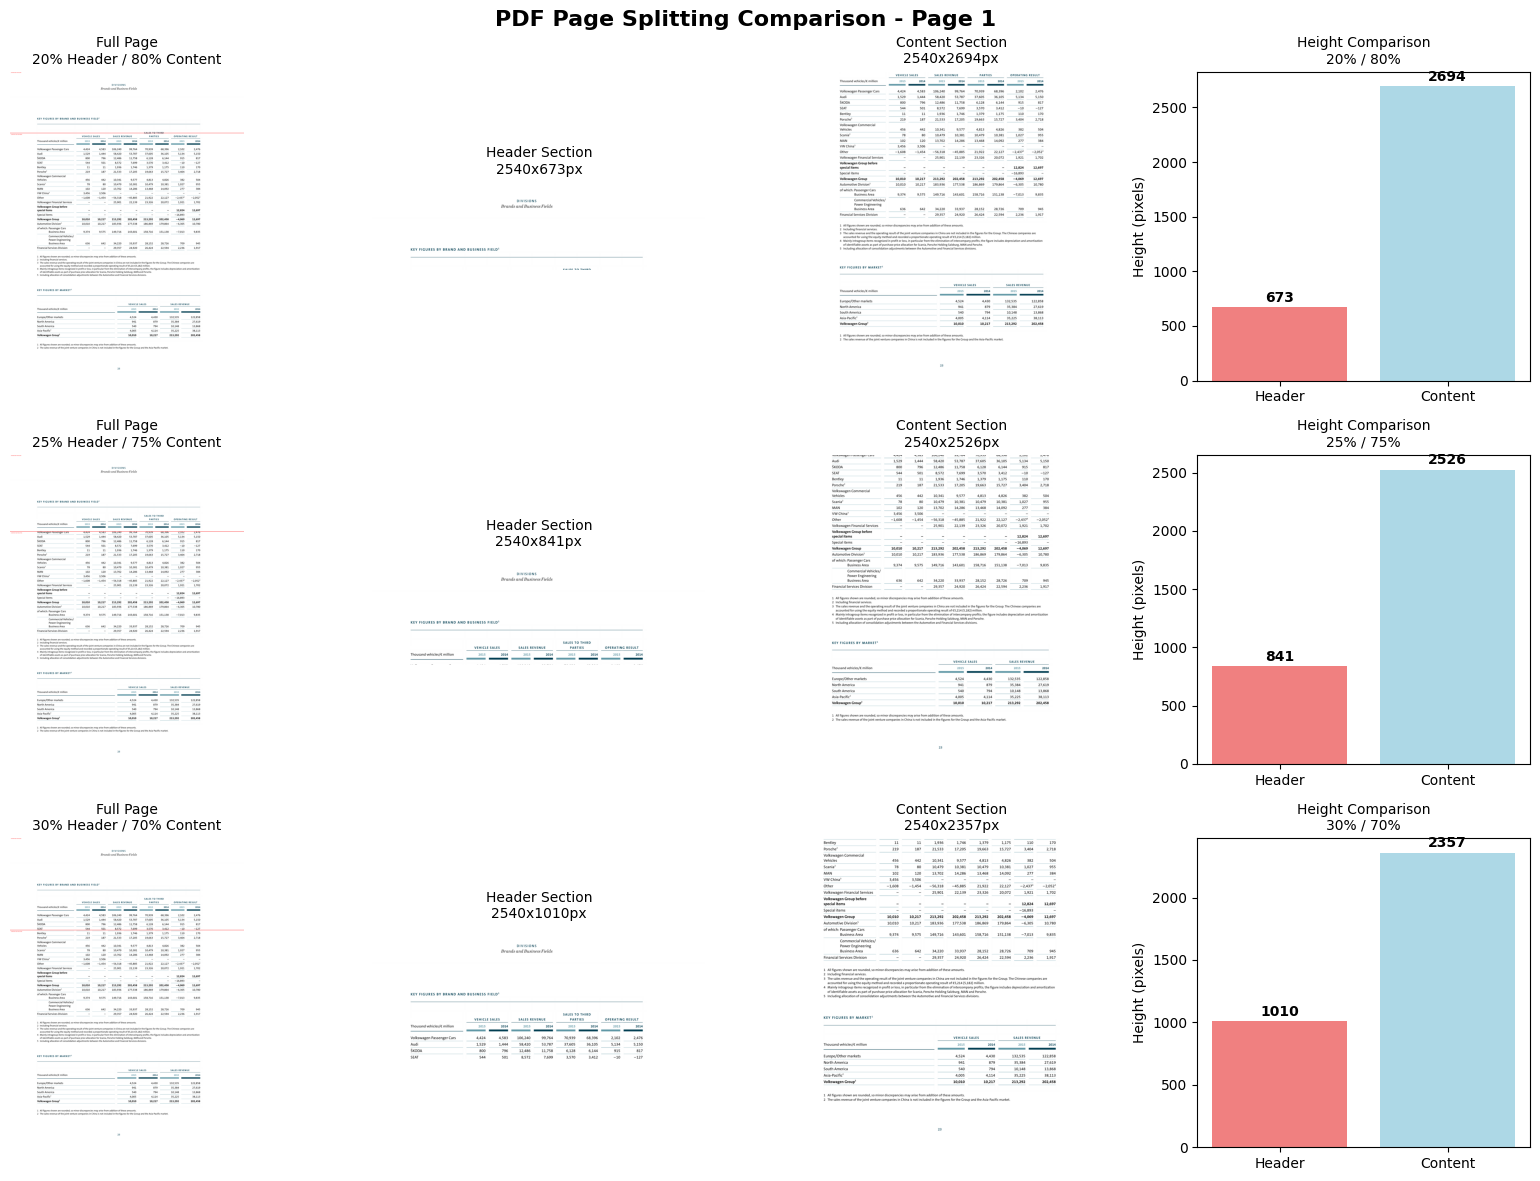


📊 SPLITTING SUMMARY:
📂 20% Header / 80% Content:
   📁 Folder: 20_80_split/
   📄 Files: 15 images
   💡 Use case: Header OCR for section detection, Content OCR for table extraction
📂 25% Header / 75% Content:
   📁 Folder: 25_75_split/
   📄 Files: 15 images
   💡 Use case: Header OCR for section detection, Content OCR for table extraction
📂 30% Header / 70% Content:
   📁 Folder: 30_70_split/
   📄 Files: 15 images
   💡 Use case: Header OCR for section detection, Content OCR for table extraction

💡 BENEFITS OF PAGE SPLITTING:
✅ Isolated header section for better section name detection
✅ Clean content section for table extraction
✅ Reduced OCR interference between headers and content
✅ Targeted processing for different content types

🎯 RECOMMENDED NEXT STEPS:
1. Run OCR separately on header and content sections
2. Use header section for section name extraction
3. Use content section for table detection
4. Compare detection accuracy vs full-page processing
5. Choose optimal split ratio based 

In [2]:
# Split PDF Pages into Header and Content Sections
import fitz  # PyMuPDF
import json
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print("Splitting PDF Pages into Header and Content Sections")
print("=" * 70)

def split_pdf_page_image(page: fitz.Page, dpi: int = 300, header_ratio: float = 0.25) -> tuple[Image.Image, Image.Image]:
    """
    Split a PDF page into two images: header section and content section.
    
    Args:
        page: PyMuPDF page object
        dpi: Resolution for rendering (default: 300 for high quality)
        header_ratio: Fraction of page height to use for header (default: 0.25 = 25%)
        
    Returns:
        Tuple of (header_image, content_image)
    """
    # Render the page at specified DPI
    zoom = dpi / 72  # 72 DPI is PDF default
    matrix = fitz.Matrix(zoom, zoom)
    pixmap = page.get_pixmap(matrix=matrix)
    
    # Convert to PIL Image
    full_image = Image.frombytes("RGB", [pixmap.width, pixmap.height], pixmap.samples)
    
    # Calculate split point
    split_y = int(full_image.height * header_ratio)
    
    # Create header section (top part)
    header_image = full_image.crop((0, 0, full_image.width, split_y))
    
    # Create content section (bottom part) 
    content_image = full_image.crop((0, split_y, full_image.width, full_image.height))
    
    return header_image, content_image

def add_split_annotation(full_image: Image.Image, split_y: int, header_ratio: float) -> Image.Image:
    """Add visual annotation showing the split line"""
    annotated_img = full_image.copy()
    draw = ImageDraw.Draw(annotated_img)
    
    # Draw split line
    draw.line([(0, split_y), (full_image.width, split_y)], fill=(255, 0, 0), width=3)
    
    # Add text labels
    try:
        font = ImageFont.load_default()
    except:
        font = None
    
    # Header label
    header_text = f"HEADER SECTION ({header_ratio*100:.0f}%)"
    draw.text((10, 10), header_text, fill=(255, 0, 0), font=font)
    
    # Content label
    content_text = f"CONTENT SECTION ({(1-header_ratio)*100:.0f}%)"
    draw.text((10, split_y + 10), content_text, fill=(255, 0, 0), font=font)
    
    return annotated_img

# Test with the PDF file
pdf_file = r"C:\Users\karim\dev\time-stamped-kpi-graph\kpi_extraction_project\data\input_test\divisions_vw_ar15.pdf"
output_dir = Path(r"C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction\split_images")
output_dir.mkdir(parents=True, exist_ok=True)

try:
    # Open the PDF document
    doc = fitz.open(pdf_file)
    print(f"📄 Processing: {Path(pdf_file).name}")
    print(f"📊 Total pages: {doc.page_count}")
    print(f"📁 Output directory: {output_dir}")
    print("=" * 70)
    
    # Test different split ratios
    split_tests = [
        (0.20, "20_80_split", "20% Header / 80% Content"),
        (0.25, "25_75_split", "25% Header / 75% Content"),  
        (0.30, "30_70_split", "30% Header / 70% Content"),
    ]
    
    # Process first 5 pages with different split ratios
    pages_to_test = min(5, doc.page_count)
    
    results_summary = {}
    
    for page_num in range(pages_to_test):
        page = doc[page_num]
        
        print(f"\n📄 PROCESSING PAGE {page_num + 1}:")
        print("-" * 50)
        
        # Get full page image for reference
        zoom = 300 / 72  # 300 DPI
        matrix = fitz.Matrix(zoom, zoom)
        pixmap = page.get_pixmap(matrix=matrix)
        full_page_image = Image.frombytes("RGB", [pixmap.width, pixmap.height], pixmap.samples)
        
        page_results = {}
        
        for header_ratio, folder_name, description in split_tests:
            print(f"✂️  Creating {description}...")
            
            # Split the image
            header_img, content_img = split_pdf_page_image(page, dpi=300, header_ratio=header_ratio)
            
            # Create subdirectory for this split test
            split_dir = output_dir / folder_name
            split_dir.mkdir(parents=True, exist_ok=True)
            
            # Save the split images
            page_prefix = f"page_{page_num + 1:02d}"
            
            # Save full page with annotation
            split_y = int(full_page_image.height * header_ratio)
            annotated_full = add_split_annotation(full_page_image, split_y, header_ratio)
            full_path = split_dir / f"{page_prefix}_full_annotated.png"
            annotated_full.save(full_path)
            
            # Save header section
            header_path = split_dir / f"{page_prefix}_header.png"
            header_img.save(header_path)
            
            # Save content section  
            content_path = split_dir / f"{page_prefix}_content.png"
            content_img.save(content_path)
            
            # Get dimensions
            full_w, full_h = full_page_image.size
            header_w, header_h = header_img.size
            content_w, content_h = content_img.size
            
            print(f"   ✅ Full page: {full_w}x{full_h}px → {full_path.name}")
            print(f"   📋 Header: {header_w}x{header_h}px → {header_path.name}")
            print(f"   📊 Content: {content_w}x{content_h}px → {content_path.name}")
            print(f"   📏 Split at: {split_y}px ({header_ratio*100:.0f}% of {full_h}px)")
            
            # Store results
            page_results[folder_name] = {
                'header_ratio': header_ratio,
                'split_y': split_y,
                'full_size': [full_w, full_h],
                'header_size': [header_w, header_h], 
                'content_size': [content_w, content_h],
                'files': {
                    'full_annotated': full_path.name,
                    'header': header_path.name,
                    'content': content_path.name
                }
            }
        
        results_summary[f'page_{page_num + 1}'] = page_results
    
    # Create a visual comparison using matplotlib
    print(f"\n🎨 Creating visual comparison...")
    
    # Show results for first page
    if pages_to_test > 0:
        fig, axes = plt.subplots(3, 4, figsize=(16, 12))
        fig.suptitle('PDF Page Splitting Comparison - Page 1', fontsize=16, fontweight='bold')
        
        page_1_dir = output_dir
        
        for row, (header_ratio, folder_name, description) in enumerate(split_tests):
            split_dir = page_1_dir / folder_name
            
            # Load images
            full_img = Image.open(split_dir / f"page_{pages_to_test:02d}_full_annotated.png")
            header_img = Image.open(split_dir / f"page_{pages_to_test:02d}_header.png") 
            content_img = Image.open(split_dir / f"page_{pages_to_test:02d}_content.png")
            
            # Plot full page
            axes[row, 0].imshow(full_img)
            axes[row, 0].set_title(f'Full Page\n{description}', fontsize=10)
            axes[row, 0].axis('off')
            
            # Plot header
            axes[row, 1].imshow(header_img)
            axes[row, 1].set_title(f'Header Section\n{header_img.size[0]}x{header_img.size[1]}px', fontsize=10)
            axes[row, 1].axis('off')
            
            # Plot content
            axes[row, 2].imshow(content_img)
            axes[row, 2].set_title(f'Content Section\n{content_img.size[0]}x{content_img.size[1]}px', fontsize=10)
            axes[row, 2].axis('off')
            
            # Show size comparison as bar chart
            sizes = [header_img.size[1], content_img.size[1]]  # Heights
            labels = ['Header', 'Content']
            colors = ['lightcoral', 'lightblue']
            
            axes[row, 3].bar(labels, sizes, color=colors)
            axes[row, 3].set_title(f'Height Comparison\n{header_ratio*100:.0f}% / {(1-header_ratio)*100:.0f}%', fontsize=10)
            axes[row, 3].set_ylabel('Height (pixels)')
            
            # Add values on bars
            for i, v in enumerate(sizes):
                axes[row, 3].text(i, v + 20, str(v), ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        
        # Save the comparison plot
        comparison_plot_path = output_dir / "splitting_comparison.png"
        plt.savefig(comparison_plot_path, dpi=150, bbox_inches='tight')
        print(f"   ✅ Comparison plot saved: {comparison_plot_path.name}")
        
        plt.show()
    
    # Save detailed results summary
    summary_file = output_dir / "splitting_results_summary.json"
    with open(summary_file, 'w', encoding='utf-8') as f:
        summary_data = {
            'source_pdf': Path(pdf_file).name,
            'pages_processed': pages_to_test,
            'split_ratios_tested': [
                {'ratio': ratio, 'description': desc} 
                for ratio, _, desc in split_tests
            ],
            'results_per_page': results_summary,
            'recommendations': {
                'best_for_headers': '20-25% typically captures section headers',
                'best_for_content': '75-80% contains tables and detailed content',
                'usage': 'Process header and content sections separately with OCR'
            }
        }
        json.dump(summary_data, f, indent=2, ensure_ascii=False)
    
    print(f"\n" + "=" * 70)
    print("📊 SPLITTING SUMMARY:")
    print("=" * 70)
    
    for split_ratio, folder_name, description in split_tests:
        folder_path = output_dir / folder_name
        if folder_path.exists():
            files = list(folder_path.glob("*.png"))
            print(f"📂 {description}:")
            print(f"   📁 Folder: {folder_name}/")
            print(f"   📄 Files: {len(files)} images")
            print(f"   💡 Use case: Header OCR for section detection, Content OCR for table extraction")
    
    print(f"\n💡 BENEFITS OF PAGE SPLITTING:")
    print("✅ Isolated header section for better section name detection")
    print("✅ Clean content section for table extraction") 
    print("✅ Reduced OCR interference between headers and content")
    print("✅ Targeted processing for different content types")
    
    print(f"\n🎯 RECOMMENDED NEXT STEPS:")
    print("1. Run OCR separately on header and content sections")
    print("2. Use header section for section name extraction")
    print("3. Use content section for table detection")
    print("4. Compare detection accuracy vs full-page processing")
    print("5. Choose optimal split ratio based on your document layout")
    
    print(f"\n📄 Summary saved: {summary_file.name}")
    print(f"🎨 Visual comparison: comparison_plot.png")
    
    doc.close()
    
    print(f"\n🎉 PAGE SPLITTING EXPERIMENT COMPLETE!")
    print("=" * 70)
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

Testing 10% Header / 90% Content Split Ratio
📄 Processing: div-divisions-vw-ar22.pdf
📊 Total pages: 23
📁 Output directory: C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction\split_images_10_90

📄 PROCESSING PAGE 1:
----------------------------------------
✂️  Creating 10% Header / 90% Content...
   ✅ Full page: 2481x3508px → page_01_full_annotated.png
   📋 Header: 2481x350px → page_01_header.png
   📊 Content: 2481x3158px → page_01_content.png
   📏 Split at: 350px (10% of 3508px)
   🎯 Header captures: Very minimal section info only
   🎯 Content captures: Maximum table and content area

📄 PROCESSING PAGE 2:
----------------------------------------
✂️  Creating 10% Header / 90% Content...
   ✅ Full page: 2481x3509px → page_02_full_annotated.png
   📋 Header: 2481x350px → page_02_header.png
   📊 Content: 2481x3159px → page_02_content.png
   📏 Split at: 350px (10% of 3509px)
   🎯 Header captures: Very minimal section info only
   🎯 Content captures: Maximum table and co

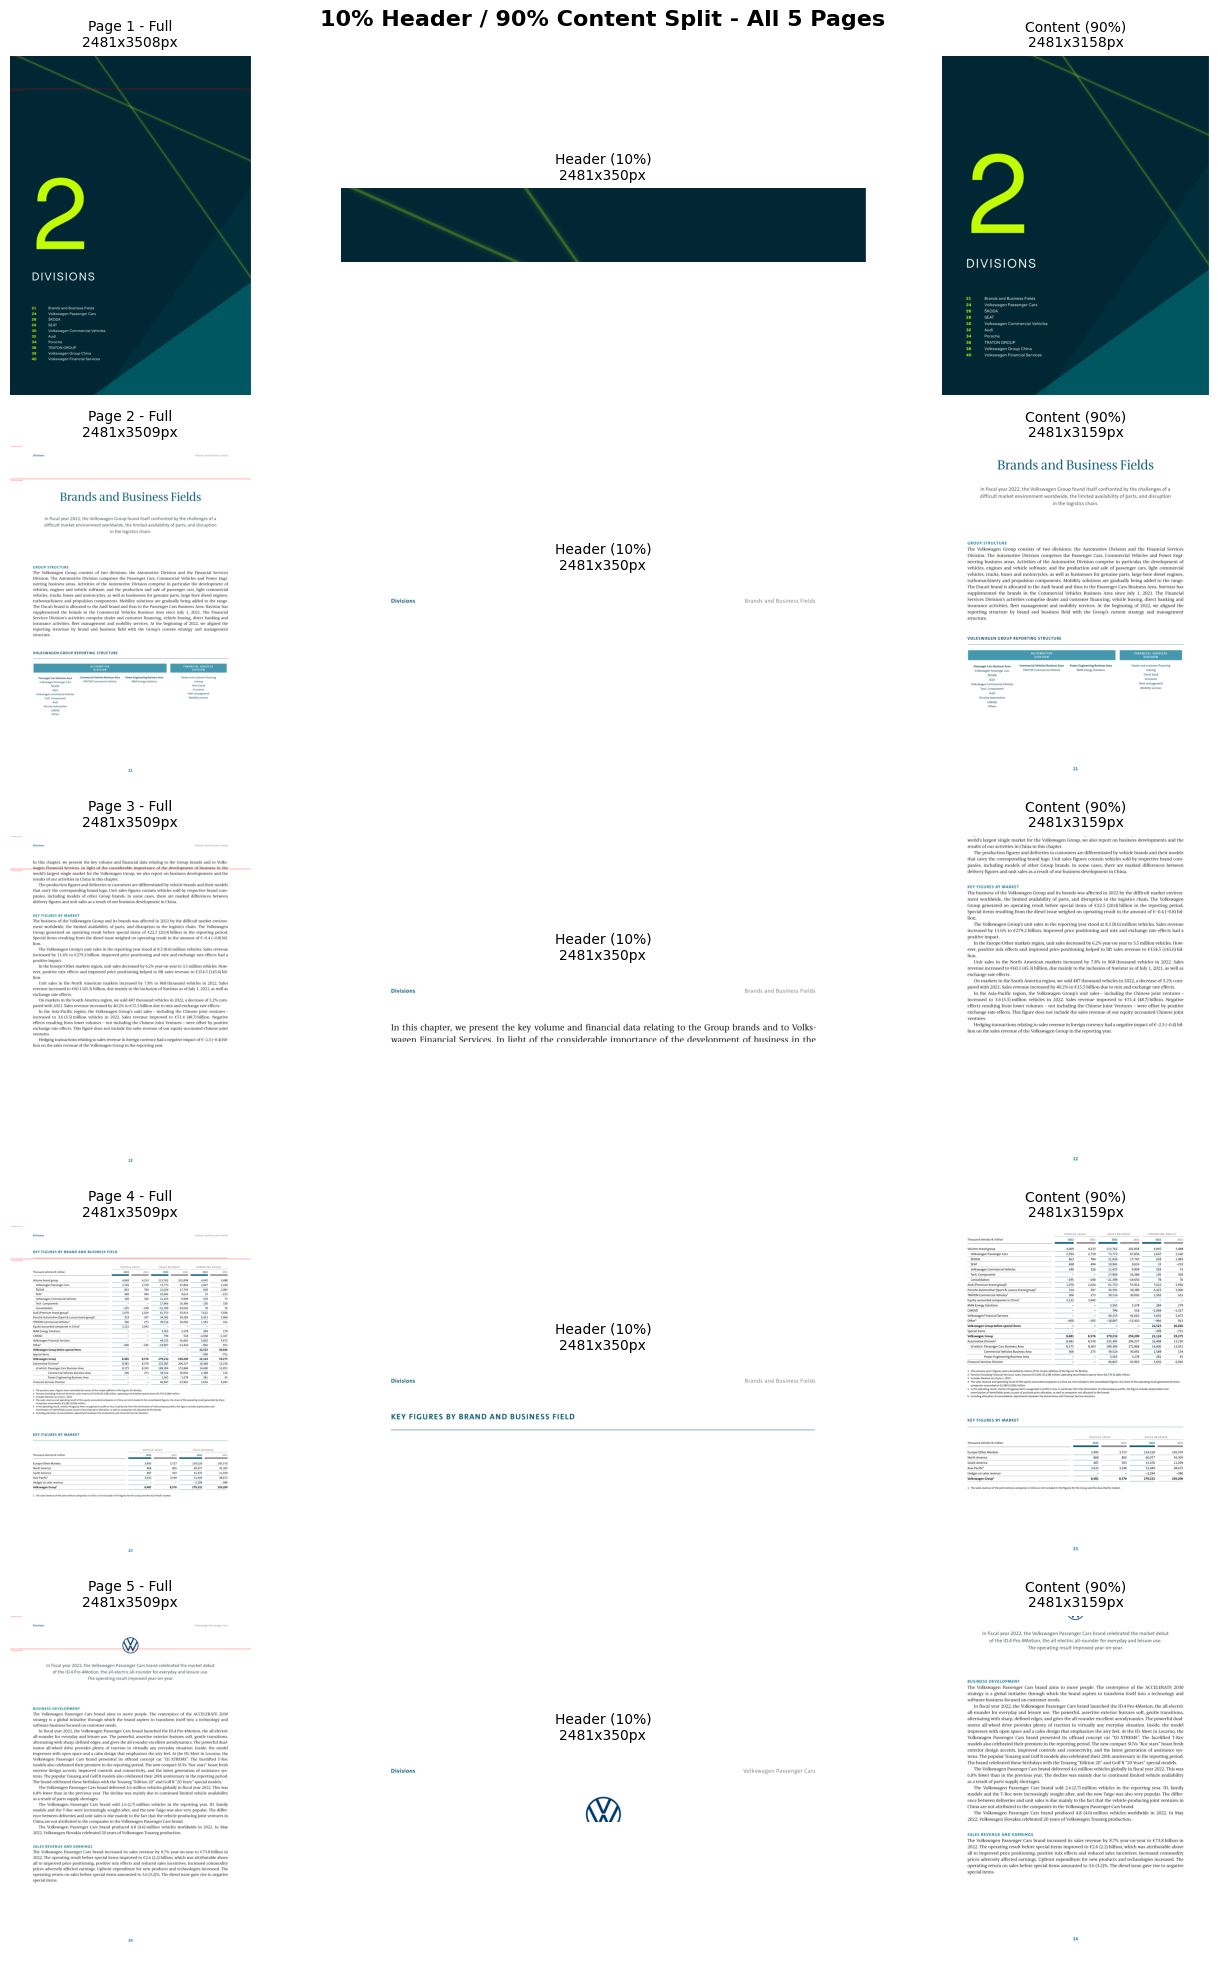


📊 10/90 SPLIT ANALYSIS:
📂 10% Header / 90% Content:
   📁 Folder: 10_90_split/
   📄 Files: 15 images (5 pages × 3 images each)
   📊 Content size: 2481x3158px
   📋 Header size: 2481x350px

💡 10/90 SPLIT CHARACTERISTICS:
✅ Maximum content area for comprehensive table detection
⚡ Minimal header interference with content processing
🎯 Best for documents with very brief section headers
⚠️  Risk: May cut off longer section titles
⚠️  Risk: Very small header area may challenge OCR accuracy

🔍 COMPARISON WITH OTHER RATIOS:
• 10/90: Maximum content, minimal header (current)
• 20/80: Balanced for brief headers
• 25/75: Standard balanced split
• 30/70: Better for longer section headers

🎯 RECOMMENDED USE CASES FOR 10/90:
1. Documents with very compact section headers
2. Maximum table detection area needed
3. Section names are already known/consistent
4. Focus on content extraction over section identification

📄 Results saved: 10_90_split_results.json
🎨 Visual comparison: 10_90_split_comparison.png

In [5]:
# Test 10% Header / 90% Content Split Ratio
import fitz  # PyMuPDF
import json
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

print("Testing 10% Header / 90% Content Split Ratio")
print("=" * 60)

def split_pdf_page_image(page: fitz.Page, dpi: int = 300, header_ratio: float = 0.10) -> tuple[Image.Image, Image.Image]:
    """
    Split a PDF page into two images: header section and content section.
    
    Args:
        page: PyMuPDF page object
        dpi: Resolution for rendering (default: 300 for high quality)
        header_ratio: Fraction of page height to use for header (default: 0.10 = 10%)
        
    Returns:
        Tuple of (header_image, content_image)
    """
    # Render the page at specified DPI
    zoom = dpi / 72  # 72 DPI is PDF default
    matrix = fitz.Matrix(zoom, zoom)
    pixmap = page.get_pixmap(matrix=matrix)
    
    # Convert to PIL Image
    full_image = Image.frombytes("RGB", [pixmap.width, pixmap.height], pixmap.samples)
    
    # Calculate split point
    split_y = int(full_image.height * header_ratio)
    
    # Create header section (top part)
    header_image = full_image.crop((0, 0, full_image.width, split_y))
    
    # Create content section (bottom part) 
    content_image = full_image.crop((0, split_y, full_image.width, full_image.height))
    
    return header_image, content_image

def add_split_annotation(full_image: Image.Image, split_y: int, header_ratio: float) -> Image.Image:
    """Add visual annotation showing the split line"""
    annotated_img = full_image.copy()
    draw = ImageDraw.Draw(annotated_img)
    
    # Draw split line
    draw.line([(0, split_y), (full_image.width, split_y)], fill=(255, 0, 0), width=3)
    
    # Add text labels
    try:
        font = ImageFont.load_default()
    except:
        font = None
    
    # Header label
    header_text = f"HEADER SECTION ({header_ratio*100:.0f}%)"
    draw.text((10, 10), header_text, fill=(255, 0, 0), font=font)
    
    # Content label
    content_text = f"CONTENT SECTION ({(1-header_ratio)*100:.0f}%)"
    draw.text((10, split_y + 10), content_text, fill=(255, 0, 0), font=font)
    
    return annotated_img

# Test with the PDF file
pdf_file = r"C:\Users\karim\dev\time-stamped-kpi-graph\kpi_extraction_project\data\input\div-divisions-vw-ar22.pdf"
output_dir = Path(r"C:\Users\karim\dev\time-stamped-kpi-graph\data\output\section_extraction\split_images_10_90")
output_dir.mkdir(parents=True, exist_ok=True)

try:
    # Open the PDF document
    doc = fitz.open(pdf_file)
    print(f"📄 Processing: {Path(pdf_file).name}")
    print(f"📊 Total pages: {doc.page_count}")
    print(f"📁 Output directory: {output_dir}")
    print("=" * 60)
    
    # Test 10/90 split ratio
    header_ratio = 0.10
    folder_name = "10_90_split"
    description = "10% Header / 90% Content"
    
    # Process first 5 pages
    pages_to_test = min(5, doc.page_count)
    
    results_summary = {}
    
    for page_num in range(pages_to_test):
        page = doc[page_num]
        
        print(f"\n📄 PROCESSING PAGE {page_num + 1}:")
        print("-" * 40)
        
        # Get full page image for reference
        zoom = 300 / 72  # 300 DPI
        matrix = fitz.Matrix(zoom, zoom)
        pixmap = page.get_pixmap(matrix=matrix)
        full_page_image = Image.frombytes("RGB", [pixmap.width, pixmap.height], pixmap.samples)
        
        print(f"✂️  Creating {description}...")
        
        # Split the image
        header_img, content_img = split_pdf_page_image(page, dpi=300, header_ratio=header_ratio)
        
        # Create subdirectory for this split test
        split_dir = output_dir / folder_name
        split_dir.mkdir(parents=True, exist_ok=True)
        
        # Save the split images
        page_prefix = f"page_{page_num + 1:02d}"
        
        # Save full page with annotation
        split_y = int(full_page_image.height * header_ratio)
        annotated_full = add_split_annotation(full_page_image, split_y, header_ratio)
        full_path = split_dir / f"{page_prefix}_full_annotated.png"
        annotated_full.save(full_path)
        
        # Save header section
        header_path = split_dir / f"{page_prefix}_header.png"
        header_img.save(header_path)
        
        # Save content section  
        content_path = split_dir / f"{page_prefix}_content.png"
        content_img.save(content_path)
        
        # Get dimensions
        full_w, full_h = full_page_image.size
        header_w, header_h = header_img.size
        content_w, content_h = content_img.size
        
        print(f"   ✅ Full page: {full_w}x{full_h}px → {full_path.name}")
        print(f"   📋 Header: {header_w}x{header_h}px → {header_path.name}")
        print(f"   📊 Content: {content_w}x{content_h}px → {content_path.name}")
        print(f"   📏 Split at: {split_y}px ({header_ratio*100:.0f}% of {full_h}px)")
        print(f"   🎯 Header captures: Very minimal section info only")
        print(f"   🎯 Content captures: Maximum table and content area")
        
        # Store results
        results_summary[f'page_{page_num + 1}'] = {
            'header_ratio': header_ratio,
            'split_y': split_y,
            'full_size': [full_w, full_h],
            'header_size': [header_w, header_h], 
            'content_size': [content_w, content_h],
            'files': {
                'full_annotated': full_path.name,
                'header': header_path.name,
                'content': content_path.name
            }
        }
    
    # Create a visual comparison showing all pages
    print(f"\n🎨 Creating visual comparison for all {pages_to_test} pages...")
    
    if pages_to_test > 0:
        # Create a grid to show all pages
        cols = 3  # full, header, content
        rows = pages_to_test
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
        if rows == 1:
            axes = axes.reshape(1, -1)  # Ensure 2D array for single row
            
        fig.suptitle(f'10% Header / 90% Content Split - All {pages_to_test} Pages', fontsize=16, fontweight='bold')
        
        split_dir = output_dir / folder_name
        
        for page_idx in range(pages_to_test):
            page_num = page_idx + 1
            
            # Load images
            full_img = Image.open(split_dir / f"page_{page_num:02d}_full_annotated.png")
            header_img = Image.open(split_dir / f"page_{page_num:02d}_header.png") 
            content_img = Image.open(split_dir / f"page_{page_num:02d}_content.png")
            
            # Plot full page
            axes[page_idx, 0].imshow(full_img)
            axes[page_idx, 0].set_title(f'Page {page_num} - Full\n{full_img.size[0]}x{full_img.size[1]}px', fontsize=10)
            axes[page_idx, 0].axis('off')
            
            # Plot header (10%)
            axes[page_idx, 1].imshow(header_img)
            axes[page_idx, 1].set_title(f'Header (10%)\n{header_img.size[0]}x{header_img.size[1]}px', fontsize=10)
            axes[page_idx, 1].axis('off')
            
            # Plot content (90%)
            axes[page_idx, 2].imshow(content_img)
            axes[page_idx, 2].set_title(f'Content (90%)\n{content_img.size[0]}x{content_img.size[1]}px', fontsize=10)
            axes[page_idx, 2].axis('off')
        
        plt.tight_layout()
        
        # Save the comparison plot
        comparison_plot_path = output_dir / "10_90_split_comparison.png"
        plt.savefig(comparison_plot_path, dpi=150, bbox_inches='tight')
        print(f"   ✅ Comparison plot saved: {comparison_plot_path.name}")
        
        plt.show()
    
    # Save detailed results summary
    summary_file = output_dir / "10_90_split_results.json"
    with open(summary_file, 'w', encoding='utf-8') as f:
        summary_data = {
            'source_pdf': Path(pdf_file).name,
            'pages_processed': pages_to_test,
            'split_ratio': {'header': 10, 'content': 90, 'description': '10% Header / 90% Content'},
            'results_per_page': results_summary,
            'analysis': {
                'header_content': 'Minimal - captures only very top section info',
                'content_content': 'Maximum - captures nearly all tables and detailed content',
                'use_case': 'When section headers are very compact and most content is tables/data',
                'pros': [
                    'Maximizes content area for table detection',
                    'Minimal header interference',
                    'Good when section titles are very brief'
                ],
                'cons': [
                    'May miss longer section titles',
                    'Very small header area for OCR',
                    'Risk of cutting off important header information'
                ]
            }
        }
        json.dump(summary_data, f, indent=2, ensure_ascii=False)
    
    print(f"\n" + "=" * 60)
    print("📊 10/90 SPLIT ANALYSIS:")
    print("=" * 60)
    
    split_dir = output_dir / folder_name
    files = list(split_dir.glob("*.png"))
    print(f"📂 10% Header / 90% Content:")
    print(f"   📁 Folder: {folder_name}/")
    print(f"   📄 Files: {len(files)} images ({pages_to_test} pages × 3 images each)")
    
    # Show size comparison
    if pages_to_test > 0:
        first_page_files = [f for f in files if f.name.startswith("page_01")]
        for file in first_page_files:
            if "header" in file.name:
                header_img = Image.open(file)
                print(f"   📋 Header size: {header_img.size[0]}x{header_img.size[1]}px")
            elif "content" in file.name and "annotated" not in file.name:
                content_img = Image.open(file)
                print(f"   📊 Content size: {content_img.size[0]}x{content_img.size[1]}px")
    
    print(f"\n💡 10/90 SPLIT CHARACTERISTICS:")
    print("✅ Maximum content area for comprehensive table detection")
    print("⚡ Minimal header interference with content processing") 
    print("🎯 Best for documents with very brief section headers")
    print("⚠️  Risk: May cut off longer section titles")
    print("⚠️  Risk: Very small header area may challenge OCR accuracy")
    
    print(f"\n🔍 COMPARISON WITH OTHER RATIOS:")
    print("• 10/90: Maximum content, minimal header (current)")
    print("• 20/80: Balanced for brief headers")
    print("• 25/75: Standard balanced split")  
    print("• 30/70: Better for longer section headers")
    
    print(f"\n🎯 RECOMMENDED USE CASES FOR 10/90:")
    print("1. Documents with very compact section headers")
    print("2. Maximum table detection area needed")
    print("3. Section names are already known/consistent")
    print("4. Focus on content extraction over section identification")
    
    print(f"\n📄 Results saved: {summary_file.name}")
    print(f"🎨 Visual comparison: 10_90_split_comparison.png")
    
    doc.close()
    
    print(f"\n🎉 10/90 SPLIT EXPERIMENT COMPLETE!")
    print("=" * 60)
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

In [7]:
# Testing PyMuPDF get_toc(simple=True) Function
import fitz  # PyMuPDF
import json
from pathlib import Path
import pandas as pd

print("Testing PyMuPDF get_toc(simple=True) Function")
print("=" * 60)

def test_get_toc_function(pdf_path: str, output_dir: str = None):
    """
    Test PyMuPDF's built-in get_toc function with different parameters.
    
    Args:
        pdf_path: Path to the PDF file
        output_dir: Optional directory to save results
        
    Returns:
        Dictionary with TOC results
    """
    
    try:
        # Open the PDF document
        doc = fitz.open(pdf_path)
        pdf_name = Path(pdf_path).name
        print(f"📄 Testing PDF: {pdf_name}")
        print(f"📊 Total pages: {doc.page_count}")
        print("=" * 60)
        
        # Test 1: Basic TOC extraction
        print("🔍 TEST 1: Basic get_toc() - Full TOC")
        print("-" * 45)
        basic_toc = doc.get_toc()
        print(f"TOC entries found: {len(basic_toc)}")
        if basic_toc:
            print("TOC entries structure:")
            for i, entry in enumerate(basic_toc[:10]):  # Show up to 10
                print(f"  {i+1}. {entry}")
            if len(basic_toc) > 10:
                print(f"  ... and {len(basic_toc) - 10} more entries")
        else:
            print("  ❌ No TOC entries found with basic get_toc()")
        
        print("\n" + "-" * 45)
        
        # Test 2: Simple TOC extraction
        print("🔍 TEST 2: get_toc(simple=True) - Simplified TOC")
        print("-" * 40)
        simple_toc = doc.get_toc(simple=True)
        print(f"Simple TOC entries found: {len(simple_toc)}")
        if simple_toc:
            print("All simple TOC entries:")
            for i, entry in enumerate(simple_toc):
                print(f"  {i+1}. {entry}")
        else:
            print("  ❌ No TOC entries found with get_toc(simple=True)")
        
        print("\n" + "-" * 40)
        
        # Test 3: Analyze TOC structure
        print("🔍 TEST 3: TOC Structure Analysis")
        print("-" * 40)
        
        toc_analysis = {
            'basic_toc_count': len(basic_toc),
            'simple_toc_count': len(simple_toc),
            'has_toc': len(basic_toc) > 0 or len(simple_toc) > 0,
            'basic_toc_sample': basic_toc[:3] if basic_toc else [],
            'simple_toc_sample': simple_toc[:3] if simple_toc else [],
            'toc_types': []
        }
        
        if basic_toc:
            # Analyze structure of basic TOC entries
            print("Basic TOC entry structure:")
            for i, entry in enumerate(basic_toc[:3]):
                print(f"  Entry {i+1}: {type(entry)} - {entry}")
                if isinstance(entry, (list, tuple)):
                    print(f"    Length: {len(entry)}")
                    if len(entry) >= 3:
                        level, title, page = entry[0], entry[1], entry[2]
                        print(f"    Level: {level}, Title: '{title}', Page: {page}")
        
        if simple_toc:
            print("\nSimple TOC entry structure:")
            for i, entry in enumerate(simple_toc[:3]):
                print(f"  Entry {i+1}: {type(entry)} - {entry}")
        
        # Test 4: Extract page mappings if TOC exists
        page_mappings = {}
        
        if basic_toc:
            print(f"\n🗺️  Creating page mappings from basic TOC:")
            for entry in basic_toc:
                if isinstance(entry, (list, tuple)) and len(entry) >= 3:
                    level, title, page_num = entry[0], entry[1], entry[2]
                    if isinstance(page_num, (int, float)) and page_num > 0:
                        # Convert to integer page number
                        page_int = int(page_num)
                        page_mappings[page_int] = {
                            'title': title.strip(),
                            'level': level,
                            'source': 'basic_toc'
                        }
                        print(f"    Page {page_int}: {title.strip()} (Level {level})")
        
        if simple_toc and not page_mappings:
            print(f"\n🗺️  Creating page mappings from simple TOC:")
            # Simple TOC might have different structure - let's explore
            for i, entry in enumerate(simple_toc):
                print(f"    Entry {i}: {entry}")
                # Try to extract page numbers if the format allows
                
        print(f"\nTotal page mappings extracted: {len(page_mappings)}")
        
        # Test 5: Compare with document outline
        print(f"\n🔍 TEST 4: Document Outline Check")
        print("-" * 40)
        try:
            outline = doc.outline
            print(f"Document outline: {outline}")
        except:
            print("No outline available or error accessing outline")
        
        # Test 6: Check document metadata
        print(f"\n🔍 TEST 5: Document Metadata")
        print("-" * 40)
        metadata = doc.metadata
        print("Document metadata:")
        for key, value in metadata.items():
            if value:
                print(f"  {key}: {value}")
        
        doc.close()
        
        # Save results if output directory specified
        results = {
            'pdf_file': pdf_name,
            'page_count': doc.page_count,
            'basic_toc': basic_toc,
            'simple_toc': simple_toc,
            'page_mappings': page_mappings,
            'analysis': toc_analysis,
            'metadata': metadata
        }
        
        if output_dir:
            output_path = Path(output_dir)
            output_path.mkdir(parents=True, exist_ok=True)
            
            # Save detailed results
            results_file = output_path / f"{Path(pdf_path).stem}_toc_test_results.json"
            with open(results_file, 'w', encoding='utf-8') as f:
                json.dump(results, f, indent=2, ensure_ascii=False)
            
            print(f"\n📁 Results saved to: {results_file}")
            
            # Create a summary CSV if page mappings found
            if page_mappings:
                df_data = []
                for page_num, info in sorted(page_mappings.items()):
                    df_data.append({
                        'page_number': page_num,
                        'section_title': info['title'],
                        'level': info['level'],
                        'source': info['source']
                    })
                
                df = pd.DataFrame(df_data)
                csv_file = output_path / f"{Path(pdf_path).stem}_page_mappings.csv"
                df.to_csv(csv_file, index=False, encoding='utf-8')
                print(f"📄 Page mappings CSV: {csv_file}")
        
        return results
        
    except Exception as e:
        print(f"❌ Error testing get_toc function: {e}")
        import traceback
        traceback.print_exc()
        return None

# Test with our PDF files
test_pdfs = [
    r"C:\Users\karim\dev\time-stamped-kpi-graph\kpi_extraction_project\data\input_test\divisions_vw_ar15.pdf",
    # Add more PDFs if available
]

# Check which PDFs exist
available_pdfs = []
for pdf_path in test_pdfs:
    if Path(pdf_path).exists():
        available_pdfs.append(pdf_path)
    else:
        print(f"⚠️  PDF not found: {pdf_path}")

if not available_pdfs:
    print("❌ No test PDFs found. Please check the file paths.")
else:
    output_dir = r"C:\Users\karim\dev\time-stamped-kpi-graph\data\output\toc_function_tests"
    
    print(f"Testing {len(available_pdfs)} PDF file(s):")
    for pdf_path in available_pdfs:
        print(f"  - {Path(pdf_path).name}")
    print("\n" + "=" * 60)
    
    all_results = {}
    
    for pdf_path in available_pdfs:
        print(f"\n📄 TESTING: {Path(pdf_path).name}")
        print("=" * 60)
        
        results = test_get_toc_function(pdf_path, output_dir)
        if results:
            all_results[Path(pdf_path).name] = results
        
        print("\n" + "🎉" + "="*58 + "🎉")
    
    # Summary across all PDFs
    if all_results:
        print(f"\n📊 SUMMARY ACROSS ALL {len(all_results)} PDF(s):")
        print("=" * 60)
        
        total_basic_entries = 0
        total_simple_entries = 0
        total_page_mappings = 0
        pdfs_with_toc = 0
        
        for pdf_name, result in all_results.items():
            basic_count = len(result.get('basic_toc', []))
            simple_count = len(result.get('simple_toc', []))
            mappings_count = len(result.get('page_mappings', {}))
            
            total_basic_entries += basic_count
            total_simple_entries += simple_count
            total_page_mappings += mappings_count
            
            if basic_count > 0 or simple_count > 0:
                pdfs_with_toc += 1
            
            print(f"📄 {pdf_name}:")
            print(f"   Basic TOC: {basic_count} entries")
            print(f"   Simple TOC: {simple_count} entries") 
            print(f"   Page mappings: {mappings_count} extracted")
        
        print(f"\n🎯 OVERALL TOTALS:")
        print(f"   PDFs with TOC: {pdfs_with_toc}/{len(all_results)}")
        print(f"   Total basic TOC entries: {total_basic_entries}")
        print(f"   Total simple TOC entries: {total_simple_entries}")
        print(f"   Total page mappings: {total_page_mappings}")
        
        if total_page_mappings > 0:
            print(f"\n✅ SUCCESS: get_toc() can extract section-to-page mappings!")
            print("💡 This could replace our manual TOC extraction approach")
        else:
            print(f"\n⚠️  No page mappings extracted - PDFs may lack embedded TOC")
            print("💡 Manual OCR-based TOC extraction may still be needed")

print(f"\n🎉 get_toc() FUNCTION TESTING COMPLETE!")
print("=" * 60)

Testing PyMuPDF get_toc(simple=True) Function - Enhanced
Testing 10 PDF file(s):
  - divisions_vw_ar15.pdf
  - div-divisions-vw-ar22.pdf
  - div-divisions-vw-ar24.pdf
  - divisions-vw-ar20.pdf
  - divisions-vw-ar21.pdf
  - divisions-vw-ar23.pdf
  - divisions_vw_ar16.pdf
  - divisions_vw_ar17.pdf
  - divisions_vw_ar18.pdf
  - divisions_vw_ar19.pdf


📄 TESTING: divisions_vw_ar15.pdf
📄 Testing PDF: divisions_vw_ar15.pdf
📊 Total pages: 28
🔍 TEST 1: Basic get_toc() - Full TOC
---------------------------------------------
TOC entries found: 0
  ❌ No TOC entries found with basic get_toc()

---------------------------------------------
🔍 TEST 2: get_toc(simple=True) - Simplified TOC
---------------------------------------------
Simple TOC entries found: 0
  ❌ No TOC entries found with get_toc(simple=True)

---------------------------------------------
🔍 TEST 3: Document Outline Analysis
---------------------------------------------
Outline object: <pymupdf.Outline object at 0x000001C7CD70BD60>